In [2]:
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt

In [16]:
# Normalize and save .tif image with compression
def normalize_image_with_compression(image_path, output_path, compression='tiff_lzw'):
    
    img = Image.open(image_path)
    img_array = np.array(img, dtype=np.float32)
    
    print(img_array.min(), img_array.max())
    
    bins = 30
    img_array_plot = img_array.flatten()
    # Plot the first histogram
    plt.hist(img_array_plot[img_array_plot>0], bins=bins, alpha=0.5, color='blue', label='before')

    # Calculate the mean intensity
    mean_intensity = np.mean(img_array[img_array>0])
    # Apply the normalization: log10(1 + raw_intensity / image_mean)
    normalized_array = np.log10(1 + (img_array / mean_intensity))
    
    # Plot the second histogram
    img_array_plot = normalized_array.flatten()
    plt.hist(img_array_plot[img_array_plot>0], bins=bins, alpha=0.5, color='red', label='after')
    # Add legend
    plt.legend()
    # Add labels and title
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title('Overlay Histogram with Transparent Colors')
    
    # Show the plot
    pltnme = output_path.split('.')[0] + ".png"
    plt.savefig(pltnme)
    
    plt.close()
    
    # Save with LZW compression (or another compression method)
    normalized_img = Image.fromarray(normalized_array)
    normalized_img.save(output_path, compression=compression)

In [8]:
Image.MAX_IMAGE_PIXELS = None

In [6]:
# Function to process all images in the folders listed in the .txt file
def process_images_in_folders(txt_file_path, output_base_folder):
    # Step 1: Read the .txt file with the folder names
    with open(txt_file_path, 'r') as f:
        folder_paths = [line.strip() for line in f.readlines()]

    # Step 2: Loop through each folder and each image file
    for folder_path in folder_paths:
        folder_path0 = folder_path[1:]
        folder_path = "/media/disk2/GCA" + folder_path0
        # Ensure the folder exists
        if os.path.isdir(folder_path):
            # Get all the image files in the folder
            for file_name in os.listdir(folder_path):
                if file_name.lower().endswith('.tif'):  # Process only .tif/.tiff files
                    input_image_path = os.path.join(folder_path, file_name)
                    
                    # Create an output path (in the same folder or different)
                    output_folder = output_base_folder + folder_path0
                    os.makedirs(output_folder, exist_ok=True)  # Create output folder if it doesn't exist
                    
                    output_image_path = os.path.join(output_folder, file_name)
                    
                    # Apply the normalization function
                    normalize_image_with_compression(input_image_path, output_image_path)
                    print(f"Processed {file_name} in {folder_path}")
        else:
            print(f"Folder not found: {folder_path}")

In [ ]:
process_images_in_folders('/media/disk2/GCA/create_dir.txt', "/media/disk2/GCA_norm")

0.0 227.0
Processed GCA002TIB_PSTAT3.tif in /media/disk2/GCA/Set01/GCA002TIB/AFRemoved
0.0 247.0
Processed GCA002TIB_ACTININ.tif in /media/disk2/GCA/Set01/GCA002TIB/AFRemoved
0.0 246.0
Processed GCA002TIB_VIMENTIN.tif in /media/disk2/GCA/Set01/GCA002TIB/AFRemoved
0.0 250.0
Processed GCA002TIB_SOX9.tif in /media/disk2/GCA/Set01/GCA002TIB/AFRemoved
0.0 248.0
Processed GCA002TIB_PEGFR.tif in /media/disk2/GCA/Set01/GCA002TIB/AFRemoved
0.0 230.0
Processed GCA002TIB_DAPI.tif in /media/disk2/GCA/Set01/GCA002TIB/AFRemoved
0.0 244.0
Processed GCA002TIB_ERBB2.tif in /media/disk2/GCA/Set01/GCA002TIB/AFRemoved
0.0 228.0
Processed GCA002TIB_FOXP3.tif in /media/disk2/GCA/Set01/GCA002TIB/AFRemoved
0.0 231.0
Processed GCA002TIB_CD45.tif in /media/disk2/GCA/Set01/GCA002TIB/AFRemoved
0.0 252.0
Processed GCA002TIB_OLFM4.tif in /media/disk2/GCA/Set01/GCA002TIB/AFRemoved
0.0 248.0
Processed GCA002TIB_MUC2.tif in /media/disk2/GCA/Set01/GCA002TIB/AFRemoved
0.0 235.0
Processed GCA002TIB_BCATENIN.tif in /media

0.0 249.0
Processed GCA012TIB_CD20.tif in /media/disk2/GCA/Set01/GCA012TIB/AFRemoved
0.0 252.0
Processed GCA012TIB_CGA.tif in /media/disk2/GCA/Set01/GCA012TIB/AFRemoved
0.0 249.0
Processed GCA012TIB_ACTG1.tif in /media/disk2/GCA/Set01/GCA012TIB/AFRemoved
0.0 252.0
Processed GCA012TIB_CD4.tif in /media/disk2/GCA/Set01/GCA012TIB/AFRemoved
0.0 254.0
Processed GCA012TIB_CD68.tif in /media/disk2/GCA/Set01/GCA012TIB/AFRemoved
0.0 252.0
Processed GCA012TIB_COLLAGEN.tif in /media/disk2/GCA/Set01/GCA012TIB/AFRemoved
0.0 247.0
Processed GCA012TIB_NAKATPASE.tif in /media/disk2/GCA/Set01/GCA012TIB/AFRemoved
0.0 252.0
Processed GCA012TIB_PEGFR.tif in /media/disk2/GCA/Set01/GCA012TIB/AFRemoved
0.0 242.0
Processed GCA012TIB_BCATENIN.tif in /media/disk2/GCA/Set01/GCA012TIB/AFRemoved
0.0 254.0
Processed GCA012TIB_CD3D.tif in /media/disk2/GCA/Set01/GCA012TIB/AFRemoved
0.0 240.0
Processed GCA012TIB_DAPI.tif in /media/disk2/GCA/Set01/GCA012TIB/AFRemoved
0.0 248.0
Processed GCA012TIB_ACTININ.tif in /media/

0.0 254.0
Processed GCA003ACA_LYSOZYME.tif in /media/disk2/GCA/Set01/GCA003ACA/AFRemoved
0.0 234.0
Processed GCA003ACA_CD45.tif in /media/disk2/GCA/Set01/GCA003ACA/AFRemoved
0.0 232.0
Processed GCA003ACA_DAPI.tif in /media/disk2/GCA/Set01/GCA003ACA/AFRemoved
0.0 205.0
Processed GCA003ACA_FOXP3.tif in /media/disk2/GCA/Set01/GCA003ACA/AFRemoved
0.0 251.0
Processed GCA003ACA_ACTININ.tif in /media/disk2/GCA/Set01/GCA003ACA/AFRemoved
0.0 246.0
Processed GCA003ACA_PEGFR.tif in /media/disk2/GCA/Set01/GCA003ACA/AFRemoved
0.0 251.0
Processed GCA003ACA_COLLAGEN.tif in /media/disk2/GCA/Set01/GCA003ACA/AFRemoved
0.0 251.0
Processed GCA003ACA_CD11B.tif in /media/disk2/GCA/Set01/GCA003ACA/AFRemoved
0.0 254.0
Processed GCA003ACA_SMA.tif in /media/disk2/GCA/Set01/GCA003ACA/AFRemoved
0.0 252.0
Processed GCA003ACA_VIMENTIN.tif in /media/disk2/GCA/Set01/GCA003ACA/AFRemoved
0.0 252.0
Processed GCA003ACA_CD4.tif in /media/disk2/GCA/Set01/GCA003ACA/AFRemoved
0.0 243.0
Processed GCA003TIB_BCATENIN.tif in /me

0.0 125.0
Processed GCA019TIA_TISSUE02_PSTAT3.tif in /media/disk2/GCA/Set03/GCA019TIA/AFRemoved
0.0 236.0
Processed GCA019TIA_TISSUE02_FOXP3.tif in /media/disk2/GCA/Set03/GCA019TIA/AFRemoved
0.0 231.0
Processed GCA019TIA_TISSUE01_CD68.tif in /media/disk2/GCA/Set03/GCA019TIA/AFRemoved
0.0 218.0
Processed GCA019TIA_TISSUE01_PANCK.tif in /media/disk2/GCA/Set03/GCA019TIA/AFRemoved
0.0 203.0
Processed GCA019TIA_TISSUE01_CD8.tif in /media/disk2/GCA/Set03/GCA019TIA/AFRemoved
0.0 219.0
Processed GCA019TIA_TISSUE02_HLAA.tif in /media/disk2/GCA/Set03/GCA019TIA/AFRemoved
0.0 244.0
Processed GCA019TIA_TISSUE02_LYSOZYME.tif in /media/disk2/GCA/Set03/GCA019TIA/AFRemoved
0.0 234.0
Processed GCA019TIA_TISSUE02_PEGFR.tif in /media/disk2/GCA/Set03/GCA019TIA/AFRemoved
0.0 213.0
Processed GCA019TIA_TISSUE02_DAPI.tif in /media/disk2/GCA/Set03/GCA019TIA/AFRemoved
0.0 208.0
Processed GCA019TIA_TISSUE02_MUC2.tif in /media/disk2/GCA/Set03/GCA019TIA/AFRemoved
0.0 233.0
Processed GCA019TIA_TISSUE02_PANCK.tif in 

In [17]:
normalize_image_with_compression("/media/disk2/GCA/Set01/GCA002ACB/AFRemoved/GCA002ACB_ACTG1.tif",
                                 "/media/disk2/GCA/Set01/GCA002ACB/AFRemoved/GCA002ACB_ACTG1_normed.tif")

0.0 246.0


In [5]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def read_image_filenames(file_path):
    with open(file_path, 'r') as file:
        filenames = [line.strip() for line in file if line.strip()]
    return filenames

def extract_intensity(image_path):
    with Image.open(image_path) as img:
        img_array = np.array(img)
        if len(img_array.shape) == 3:  # Check if the image is RGB
            img_array = img_array.mean(axis=2)  # Convert to grayscale by averaging channels
        return img_array.flatten()

def create_histogram(intensities, bins=256, alpha=0.5, color='blue'):
    plt.hist(intensities, bins=bins, alpha=alpha, color=color)

def main(file_name):
    filenames = read_image_filenames(file_name)
    plt.figure()
    
    for idx, filename in enumerate(filenames):
        if os.path.exists(filename):
            intensities = extract_intensity(filename)
            create_histogram(intensities, alpha=0.5, color=f'C{idx}')
        else:
            print(f"File not found: {filename}")

    plt.xlabel('Intensity Value')
    plt.ylabel('Frequency')
    plt.title('Intensity Histogram')
    plt.legend([os.path.basename(f) for f in filenames], loc='upper right')
    plt.show()


In [6]:
filenames = read_image_filenames('/media/disk2/GCA/CREATE_DIR.txt')
individuals = []
for filename in filenames:
    individuals.append(filename.split("/")[2])
    
filenames = os.listdir("/media/disk2/GCA/Set01/GCA002ACB/AFRemoved")
markers = []
for filename in filenames:
    init1 = filename.split("_")[1]
    markers.append(init1.split(".")[0])

In [2]:
import random
filenames = read_image_filenames('/media/disk2/GCA/create_dir_cp.txt')
for marker in markers:
    image_ps = []
    for filename in filenames:
        sample = filename.split("/")[2]
        image_ps.append("/media/disk2/GCA_norm"+filename[1:]+"/"+sample+"_"+marker+".tif")
 
    plt.figure()
    
    for idx, filename in enumerate(image_ps):
        print(filename)
        if os.path.exists(filename):
            intensities = extract_intensity(filename)
            # Take a simple random sample of 2000 elements
            sample = np.random.choice(intensities[intensities>0], 2000, replace=True)
            create_histogram(sample, bins=100 ,alpha=0.2, color=f'C{idx}')
        else:
            print(f"File not found: {filename}")
    
    plt.xlabel('Intensity Value')
    plt.ylabel('Frequency')
    plt.title(marker)
    plt.legend([os.path.basename(f) for f in filenames], loc='upper right')
    plt.show()
        


NameError: name 'read_image_filenames' is not defined

In [30]:
plt.close()

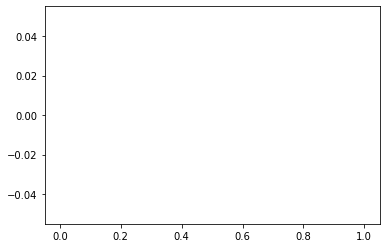

In [35]:
plt.figure()
intensities = extract_intensity("/media/disk2/GCA_norm/Set06/GCA112ACB/AFRemoved/GCA112ACB_CD8.tif")
create_histogram(intensities[intensities>0], bins=100 ,alpha=0.2, color=f'C{idx}')
plt.show()

In [20]:
type(extract_intensity("/media/disk2/GCA/Set01/GCA002ACB/AFRemoved/GCA002ACB_ACTG1.tif"))

numpy.ndarray

In [24]:
filenames = read_image_filenames('/media/disk2/GCA/CREATE_DIR.txt')
for filename in filenames:
    filename = "/media/disk2/GCA"+filename[1:]+"/"
    files = os.listdir(filename)
    print(filename)
    for file in files:
        file = filename + file
        if os.path.exists(file):
            if file.endswith('.tif'):
                intensities = extract_intensity(file)
        else:
            print(f"File not found: {file}")
        if np.count_nonzero(np.isnan(intensities)) > 0:
            print(file)
            print(intensities.size)
            print(np.count_nonzero(np.isnan(intensities)))


/media/disk2/GCA/Set01/GCA002TIB/AFRemoved/
/media/disk2/GCA/Set01/GCA011ACB/AFRemoved/
/media/disk2/GCA/Set01/GCA012ACB/AFRemoved/
/media/disk2/GCA/Set01/GCA012TIB/AFRemoved/
/media/disk2/GCA/Set01/GCA004TIB/AFRemoved/
/media/disk2/GCA/Set01/GCA002ACB/AFRemoved/
/media/disk2/GCA/Set01/GCA003ACA/AFRemoved/
/media/disk2/GCA/Set01/GCA003TIB/AFRemoved/
/media/disk2/GCA/Set01/GCA011TIB/AFRemoved/
/media/disk2/GCA/Set03/GCA019TIA/AFRemoved/
/media/disk2/GCA/Set03/GCA019ACA/AFRemoved/
/media/disk2/GCA/Set03/GCA054TIA/AFRemoved/
/media/disk2/GCA/Set03/GCA054ACB/AFRemoved/
/media/disk2/GCA/Set03/GCA062TIA/AFRemoved/
/media/disk2/GCA/Set03/GCA062ACA/AFRemoved/
/media/disk2/GCA/Set03/GCA066TIB/AFRemoved/
/media/disk2/GCA/Set03/GCA066ACB/AFRemoved/
/media/disk2/GCA/Set03/GCA069TIB/AFRemoved/
/media/disk2/GCA/Set03/GCA069ACB/AFRemoved/
/media/disk2/GCA/Set03/GCA071TIA/AFRemoved/
/media/disk2/GCA/Set03/GCA071ACB/AFRemoved/
/media/disk2/GCA/Set03/GCA072TIB/AFRemoved/
/media/disk2/GCA/Set03/GCA072ACB

In [19]:
os.listdir(filename)

['GCA011ACB_OLFM4.tif',
 'GCA011ACB_CD20.tif',
 'GCA011ACB_SMA.tif',
 'GCA011ACB_VIMENTIN.tif',
 'GCA011ACB_FOXP3.tif',
 'GCA011ACB_ACTININ.tif',
 'GCA011ACB_HLAA.tif',
 'GCA011ACB_LYSOZYME.tif',
 'GCA011ACB_CD3D.tif',
 'GCA011ACB_NAKATPASE.tif',
 'GCA011ACB_BCATENIN.tif',
 'GCA011ACB_CD45.tif',
 'GCA011ACB_SOX9.tif',
 'GCA011ACB_PSTAT3.tif',
 'GCA011ACB_CD68.tif',
 'GCA011ACB_CD11B.tif',
 'GCA011ACB_PCNA.tif',
 'GCA011ACB_SNA.tif',
 'GCA011ACB_CD4.tif',
 'GCA011ACB_PEGFR.tif',
 'GCA011ACB_MUC2.tif',
 'GCA011ACB_DAPI.tif',
 'GCA011ACB_ACTG1.tif',
 'GCA011ACB_COLLAGEN.tif',
 'GCA011ACB_COX2.tif',
 'GCA011ACB_CD8.tif',
 'GCA011ACB_PANCK.tif',
 'GCA011ACB_ERBB2.tif',
 'GCA011ACB_CGA.tif']

In [58]:
os.path.isfile("/media/disk2/GCA/Set01/GCA002TIB/AFRemoved/GCA002TIB_PSTAT3.tif")

True

In [42]:
marker="CD68"

/media/disk2/GCA/Set01/GCA002TIB/AFRemoved/GCA002TIB_CD68.tif
/media/disk2/GCA/Set01/GCA011ACB/AFRemoved/GCA011ACB_CD68.tif
/media/disk2/GCA/Set01/GCA012ACB/AFRemoved/GCA012ACB_CD68.tif
/media/disk2/GCA/Set01/GCA012TIB/AFRemoved/GCA012TIB_CD68.tif
/media/disk2/GCA/Set01/GCA004TIB/AFRemoved/GCA004TIB_CD68.tif
/media/disk2/GCA/Set01/GCA002ACB/AFRemoved/GCA002ACB_CD68.tif
/media/disk2/GCA/Set01/GCA003ACA/AFRemoved/GCA003ACA_CD68.tif
/media/disk2/GCA/Set01/GCA003TIB/AFRemoved/GCA003TIB_CD68.tif
/media/disk2/GCA/Set01/GCA011TIB/AFRemoved/GCA011TIB_CD68.tif
/media/disk2/GCA/Set03/GCA019TIA/AFRemoved/GCA019TIA_CD68.tif
File not found: /media/disk2/GCA/Set03/GCA019TIA/AFRemoved/GCA019TIA_CD68.tif
/media/disk2/GCA/Set03/GCA019ACA/AFRemoved/GCA019ACA_CD68.tif
/media/disk2/GCA/Set03/GCA054TIA/AFRemoved/GCA054TIA_CD68.tif
File not found: /media/disk2/GCA/Set03/GCA054TIA/AFRemoved/GCA054TIA_CD68.tif
/media/disk2/GCA/Set03/GCA054ACB/AFRemoved/GCA054ACB_CD68.tif
File not found: /media/disk2/GCA/Set03

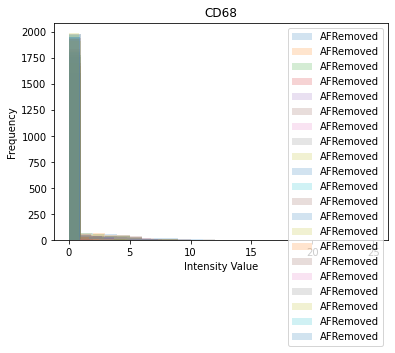

In [50]:
image_ps = []
for filename in filenames:
    sample = filename.split("/")[2]
    image_ps.append("/media/disk2/GCA"+filename[1:]+"/"+sample+"_"+marker+".tif")

plt.figure()

for idx, filename in enumerate(image_ps):
    print(filename)
    if os.path.exists(filename):
        intensities = extract_intensity(filename)
        # Take a simple random sample of 2000 elements
        sample = np.random.choice(intensities[(intensities >= 0) & (intensities <= 25)], 2000, replace=True)
        create_histogram(sample, bins=25 ,alpha=0.2, color=f'C{idx}')
    else:
        print(f"File not found: {filename}")

plt.xlabel('Intensity Value')
plt.ylabel('Frequency')
plt.title(marker)
plt.legend([os.path.basename(f) for f in filenames], loc='upper right')
plt.show()

In [49]:
plt.close()

In [3]:
def rename_files_to_uppercase(directory):
    # List all files in the specified directory
    for filename in os.listdir(directory):
        # Split the filename and the extension
        name, ext = os.path.splitext(filename)
        
        # Convert the name to uppercase and keep the extension unchanged
        new_name = name.upper() + ext
        
        # Define the full paths for the old and new file names
        old_file_path = os.path.join(directory, filename)
        new_file_path = os.path.join(directory, new_name)
        
        # Rename the file if the new name is different
        if old_file_path != new_file_path:
            os.rename(old_file_path, new_file_path)
            print(f'Renamed: {filename} -> {new_name}')

# Example usage
# Replace 'path/to/your/directory' with your actual directory path
rename_files_to_uppercase('/media/disk2/GCA_norm/')

Renamed: Set06 -> SET06
Renamed: plots.RData -> PLOTS.RData
Renamed: Set01 -> SET01
Renamed: Set03 -> SET03
Renamed: Set02 -> SET02


In [6]:
filenames = read_image_filenames('/media/disk2/GCA/CREATE_DIR.txt')
for filename in filenames:
    filename = "/media/disk2/GCA_norm"+filename[1:]+"/"
    rename_files_to_uppercase(filename)

Renamed: GCA020TIB_TISSUE02_CgA.tif -> GCA020TIB_TISSUE02_CGA.tif
Renamed: GCA020TIB_TISSUE01_Collagen.png -> GCA020TIB_TISSUE01_COLLAGEN.png
Renamed: GCA020TIB_TISSUE01_PanCK.tif -> GCA020TIB_TISSUE01_PANCK.tif
Renamed: GCA020TIB_TISSUE01_CD3d.tif -> GCA020TIB_TISSUE01_CD3D.tif
Renamed: GCA020TIB_TISSUE03_Muc2.tif -> GCA020TIB_TISSUE03_MUC2.tif
Renamed: GCA020TIB_TISSUE03_Vimentin.png -> GCA020TIB_TISSUE03_VIMENTIN.png
Renamed: GCA020TIB_TISSUE01_Lysozyme.png -> GCA020TIB_TISSUE01_LYSOZYME.png
Renamed: GCA020TIB_TISSUE03_pEGFR.tif -> GCA020TIB_TISSUE03_PEGFR.tif
Renamed: GCA020TIB_TISSUE01_PanCK.png -> GCA020TIB_TISSUE01_PANCK.png
Renamed: GCA020TIB_TISSUE01_Vimentin.png -> GCA020TIB_TISSUE01_VIMENTIN.png
Renamed: GCA020TIB_TISSUE02_Vimentin.tif -> GCA020TIB_TISSUE02_VIMENTIN.tif
Renamed: GCA020TIB_TISSUE01_Muc2.tif -> GCA020TIB_TISSUE01_MUC2.tif
Renamed: GCA020TIB_TISSUE01_CD3d.png -> GCA020TIB_TISSUE01_CD3D.png
Renamed: GCA020TIB_TISSUE03_PanCK.png -> GCA020TIB_TISSUE03_PANCK.png
Re

Renamed: GCA020ACB_TISSUE02_NaKATPase.png -> GCA020ACB_TISSUE02_NAKATPASE.png
Renamed: GCA020ACB_TISSUE01_Collagen.png -> GCA020ACB_TISSUE01_COLLAGEN.png
Renamed: GCA020ACB_TISSUE01_CD3d.png -> GCA020ACB_TISSUE01_CD3D.png
Renamed: GCA020ACB_TISSUE02_PanCK.png -> GCA020ACB_TISSUE02_PANCK.png
Renamed: GCA020ACB_TISSUE01_PanCK.png -> GCA020ACB_TISSUE01_PANCK.png
Renamed: GCA020ACB_TISSUE03_pEGFR.png -> GCA020ACB_TISSUE03_PEGFR.png
Renamed: GCA020ACB_TISSUE02_Sox9.tif -> GCA020ACB_TISSUE02_SOX9.tif
Renamed: GCA020ACB_TISSUE03_Vimentin.png -> GCA020ACB_TISSUE03_VIMENTIN.png
Renamed: GCA020ACB_TISSUE03_Muc2.png -> GCA020ACB_TISSUE03_MUC2.png
Renamed: GCA020ACB_TISSUE01_Lysozyme.png -> GCA020ACB_TISSUE01_LYSOZYME.png
Renamed: GCA020ACB_TISSUE01_PanCK.tif -> GCA020ACB_TISSUE01_PANCK.tif
Renamed: GCA020ACB_TISSUE01_Muc2.png -> GCA020ACB_TISSUE01_MUC2.png
Renamed: GCA020ACB_TISSUE01_CgA.tif -> GCA020ACB_TISSUE01_CGA.tif
Renamed: GCA020ACB_TISSUE02_CD3d.png -> GCA020ACB_TISSUE02_CD3D.png
Renamed:

Renamed: GCA022ACB_TISSUE01_Cox2.png -> GCA022ACB_TISSUE01_COX2.png
Renamed: GCA022ACB_TISSUE03_NaKATPase.tif -> GCA022ACB_TISSUE03_NAKATPASE.tif
Renamed: GCA022ACB_TISSUE03_Cox2.png -> GCA022ACB_TISSUE03_COX2.png
Renamed: GCA022ACB_TISSUE02_NaKATPase.png -> GCA022ACB_TISSUE02_NAKATPASE.png
Renamed: GCA022ACB_TISSUE02_CD3d.tif -> GCA022ACB_TISSUE02_CD3D.tif
Renamed: GCA022ACB_TISSUE02_CD3d.png -> GCA022ACB_TISSUE02_CD3D.png
Renamed: GCA022ACB_TISSUE02_Muc2.tif -> GCA022ACB_TISSUE02_MUC2.tif
Renamed: GCA022ACB_TISSUE02_Cox2.tif -> GCA022ACB_TISSUE02_COX2.tif
Renamed: GCA022ACB_TISSUE03_Collagen.png -> GCA022ACB_TISSUE03_COLLAGEN.png
Renamed: GCA022ACB_TISSUE01_pSTAT3.tif -> GCA022ACB_TISSUE01_PSTAT3.tif
Renamed: GCA022ACB_TISSUE03_Vimentin.tif -> GCA022ACB_TISSUE03_VIMENTIN.tif
Renamed: GCA022ACB_TISSUE02_Collagen.png -> GCA022ACB_TISSUE02_COLLAGEN.png
Renamed: GCA022ACB_TISSUE02_CgA.tif -> GCA022ACB_TISSUE02_CGA.tif
Renamed: GCA022ACB_TISSUE01_CgA.png -> GCA022ACB_TISSUE01_CGA.png
Rena

Renamed: GCA033ACB_TISSUE02_pEGFR.png -> GCA033ACB_TISSUE02_PEGFR.png
Renamed: GCA033ACB_TISSUE02_Vimentin.tif -> GCA033ACB_TISSUE02_VIMENTIN.tif
Renamed: GCA033ACB_TISSUE01_Lysozyme.tif -> GCA033ACB_TISSUE01_LYSOZYME.tif
Renamed: GCA033ACB_TISSUE01_pEGFR.png -> GCA033ACB_TISSUE01_PEGFR.png
Renamed: GCA033ACB_TISSUE01_Muc2.tif -> GCA033ACB_TISSUE01_MUC2.tif
Renamed: GCA033ACB_TISSUE02_Lysozyme.tif -> GCA033ACB_TISSUE02_LYSOZYME.tif
Renamed: GCA033ACB_TISSUE01_Lysozyme.png -> GCA033ACB_TISSUE01_LYSOZYME.png
Renamed: GCA033ACB_TISSUE02_Collagen.tif -> GCA033ACB_TISSUE02_COLLAGEN.tif
Renamed: GCA033ACB_TISSUE01_Cox2.tif -> GCA033ACB_TISSUE01_COX2.tif
Renamed: GCA033ACB_TISSUE01_Collagen.png -> GCA033ACB_TISSUE01_COLLAGEN.png
Renamed: GCA033ACB_TISSUE02_Cox2.png -> GCA033ACB_TISSUE02_COX2.png
Renamed: GCA033ACB_TISSUE01_NaKATPase.tif -> GCA033ACB_TISSUE01_NAKATPASE.tif
Renamed: GCA033ACB_TISSUE01_Cox2.png -> GCA033ACB_TISSUE01_COX2.png
Renamed: GCA033ACB_TISSUE01_Vimentin.tif -> GCA033ACB_

Renamed: GCA035ACB_TISSUE03_NaKATPase.png -> GCA035ACB_TISSUE03_NAKATPASE.png
Renamed: GCA035ACB_TISSUE01_Sox9.tif -> GCA035ACB_TISSUE01_SOX9.tif
Renamed: GCA035ACB_TISSUE03_pEGFR.png -> GCA035ACB_TISSUE03_PEGFR.png
Renamed: GCA035ACB_TISSUE01_Cox2.tif -> GCA035ACB_TISSUE01_COX2.tif
Renamed: GCA035ACB_TISSUE03_PanCK.tif -> GCA035ACB_TISSUE03_PANCK.tif
Renamed: GCA035ACB_TISSUE01_Cox2.png -> GCA035ACB_TISSUE01_COX2.png
Renamed: GCA035ACB_TISSUE01_Muc2.png -> GCA035ACB_TISSUE01_MUC2.png
Renamed: GCA035ACB_TISSUE02_Collagen.png -> GCA035ACB_TISSUE02_COLLAGEN.png
Renamed: GCA035ACB_TISSUE01_Muc2.tif -> GCA035ACB_TISSUE01_MUC2.tif
Renamed: GCA035ACB_TISSUE02_Cox2.tif -> GCA035ACB_TISSUE02_COX2.tif
Renamed: GCA035ACB_TISSUE03_CgA.tif -> GCA035ACB_TISSUE03_CGA.tif
Renamed: GCA035ACB_TISSUE03_Muc2.tif -> GCA035ACB_TISSUE03_MUC2.tif
Renamed: GCA035ACB_TISSUE01_pSTAT3.png -> GCA035ACB_TISSUE01_PSTAT3.png
Renamed: GCA035ACB_TISSUE02_PanCK.tif -> GCA035ACB_TISSUE02_PANCK.tif
Renamed: GCA035ACB_TIS

Renamed: GCA039ACB_TISSUE01_Vimentin.tif -> GCA039ACB_TISSUE01_VIMENTIN.tif
Renamed: GCA039ACB_TISSUE01_CD3d.png -> GCA039ACB_TISSUE01_CD3D.png
Renamed: GCA039ACB_TISSUE02_Lysozyme.tif -> GCA039ACB_TISSUE02_LYSOZYME.tif
Renamed: GCA039ACB_TISSUE02_NaKATPase.tif -> GCA039ACB_TISSUE02_NAKATPASE.tif
Renamed: GCA039ACB_TISSUE02_Sox9.png -> GCA039ACB_TISSUE02_SOX9.png
Renamed: GCA039ACB_TISSUE02_Vimentin.tif -> GCA039ACB_TISSUE02_VIMENTIN.tif
Renamed: GCA039ACB_TISSUE01_pSTAT3.tif -> GCA039ACB_TISSUE01_PSTAT3.tif
Renamed: GCA039ACB_TISSUE02_Cox2.tif -> GCA039ACB_TISSUE02_COX2.tif
Renamed: GCA039ACB_TISSUE02_Collagen.tif -> GCA039ACB_TISSUE02_COLLAGEN.tif
Renamed: GCA039ACB_TISSUE01_Muc2.tif -> GCA039ACB_TISSUE01_MUC2.tif
Renamed: GCA039ACB_TISSUE02_Cox2.png -> GCA039ACB_TISSUE02_COX2.png
Renamed: GCA039ACB_TISSUE02_NaKATPase.png -> GCA039ACB_TISSUE02_NAKATPASE.png
Renamed: GCA039ACB_TISSUE02_pSTAT3.png -> GCA039ACB_TISSUE02_PSTAT3.png
Renamed: GCA039ACB_TISSUE01_Muc2.png -> GCA039ACB_TISSUE

Renamed: GCA059TIB_TISSUE02_CD3d.tif -> GCA059TIB_TISSUE02_CD3D.tif
Renamed: GCA059TIB_TISSUE02_Sox9.tif -> GCA059TIB_TISSUE02_SOX9.tif
Renamed: GCA059TIB_TISSUE02_CD3d.png -> GCA059TIB_TISSUE02_CD3D.png
Renamed: GCA059TIB_TISSUE02_Lysozyme.tif -> GCA059TIB_TISSUE02_LYSOZYME.tif
Renamed: GCA059TIB_TISSUE03_CD3d.tif -> GCA059TIB_TISSUE03_CD3D.tif
Renamed: GCA059TIB_TISSUE03_Muc2.tif -> GCA059TIB_TISSUE03_MUC2.tif
Renamed: GCA059TIB_TISSUE01_Muc2.png -> GCA059TIB_TISSUE01_MUC2.png
Renamed: GCA059TIB_TISSUE01_pEGFR.tif -> GCA059TIB_TISSUE01_PEGFR.tif
Renamed: GCA059TIB_TISSUE02_pSTAT3.tif -> GCA059TIB_TISSUE02_PSTAT3.tif
Renamed: GCA059TIB_TISSUE03_CD3d.png -> GCA059TIB_TISSUE03_CD3D.png
Renamed: GCA059TIB_TISSUE03_PanCK.png -> GCA059TIB_TISSUE03_PANCK.png
Renamed: GCA059TIB_TISSUE02_Collagen.png -> GCA059TIB_TISSUE02_COLLAGEN.png
Renamed: GCA059TIB_TISSUE02_Cox2.tif -> GCA059TIB_TISSUE02_COX2.tif
Renamed: GCA059TIB_TISSUE01_NaKATPase.tif -> GCA059TIB_TISSUE01_NAKATPASE.tif
Renamed: GCA05